# Financial Event Sequencing
**Core Pattern:** Ordered Analytical Window / Top-N by Group

Find the top 5 positive, plausible fare events for each pickup day.

In [1]:
import sys, os

try:
    import datapunk  # noqa: F401
except ImportError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

os.environ["DAFT_PROGRESS_BAR"] = "0"
import plotly.io as pio

pio.renderers.default = "svg"

from datapunk.reporter import DatapunkReporter

RAM_CAP = 1024  # in MB

reporter = DatapunkReporter(
    small_months=1,
    large_cap_mb=RAM_CAP,
    with_lookup=False,
)

  ⚙ unifying schema across 24 files (20 cols)…
     ✅ unified files cached.


Datapunk Environment
----------------------------------------------------
  OS:        Darwin 25.3.0
  CPU:       Apple M1 Pro (8 cores)
  RAM:       16.0 GB
  Python:    v3.14.6
  Small run: 1 month, uncapped, 5 iter + 1 warmup
  Large run: 24 months, cap = 1024 MB (physical RSS), 1 iter + 0 warmup
----------------------------------------------------


## Analytics Functions

In [2]:
# Ordered top-N analytics at scale.
#
# Semantics: top 5 positive, plausible fare events per pickup day, with a 1-based
# row_number-like fare_rank in descending fare order. Broad sanity bounds reduce
# the chance that one obvious meter/GPS anomaly dominates the story.
#
# Important: TLC monthly files can contain a small number of records whose
# tpep_pickup_datetime falls outside the file month. Because this suite groups by
# pickup_date, those rows would create misleading extra dates on the x-axis and
# extra groups in the benchmark. We bound pickup timestamps to the month span
# implied by the file names passed to the function.
#
# Each engine uses its own native API and returns its native materialized output.
# Polars is run twice (default and streaming engine). DuckDB is run twice
# (default and with an explicit memory limit). Dask uses the threaded scheduler.

TOP_N = 5
TAXI_COLS = ["tpep_pickup_datetime", "fare_amount", "trip_distance"]
OUT_COLS = ["pickup_date", "fare_amount", "fare_rank"]
PARQUET_FILTERS = [
    [
        ("fare_amount", ">", 0.0),
        ("fare_amount", "<", 500.0),
        ("trip_distance", ">", 0.0),
        ("trip_distance", "<", 100.0),
    ]
]


def _month_bounds_from_paths(file_path):
    """Return [start_ts, end_ts) implied by yellow_tripdata_YYYY-MM filenames."""
    import os
    import re
    from datetime import datetime

    months = []
    for path in file_path:
        match = re.search(
            r"yellow_tripdata_(\d{4})-(\d{2})", os.path.basename(str(path))
        )
        if match:
            months.append((int(match.group(1)), int(match.group(2))))
    if not months:
        return None, None

    start_year, start_month = min(months)
    end_year, end_month = max(months)
    start_ts = datetime(start_year, start_month, 1)
    if end_month == 12:
        end_ts = datetime(end_year + 1, 1, 1)
    else:
        end_ts = datetime(end_year, end_month + 1, 1)
    return start_ts, end_ts


def _bounded_parquet_filters(start_ts, end_ts):
    filters = list(PARQUET_FILTERS[0])
    if start_ts is not None and end_ts is not None:
        filters += [
            ("tpep_pickup_datetime", ">=", start_ts),
            ("tpep_pickup_datetime", "<", end_ts),
        ]
    return [filters]


def _empty_pandas_topn():
    import pandas as pd

    return pd.DataFrame(
        {
            "pickup_date": pd.Series(dtype="datetime64[ns]"),
            "fare_amount": pd.Series(dtype="float64"),
            "fare_rank": pd.Series(dtype="int64"),
        }
    )


def _rank_topn_pandas(df):
    """Pandas-only bounded top-N-per-day helper."""
    if df is None or len(df) == 0:
        return _empty_pandas_topn()

    df = df[["pickup_date", "fare_amount"]].dropna()
    if df.empty:
        return _empty_pandas_topn()

    # groupby().nlargest(TOP_N) keeps only TOP_N candidates per pickup_date instead
    # of sorting/materializing every row in every group.
    s = df.groupby("pickup_date", sort=False)["fare_amount"].nlargest(TOP_N)
    out = s.rename("fare_amount").reset_index(level=0).reset_index(drop=True)
    out = out.sort_values(
        ["pickup_date", "fare_amount"], ascending=[True, False], kind="mergesort"
    )
    out["fare_rank"] = out.groupby("pickup_date", sort=False).cumcount() + 1
    return out[OUT_COLS]


def _duckdb_materialize(query, params, *, capped=False):
    import duckdb
    import uuid
    from datapunk.fingerprint import DuckDBTableResult

    con = duckdb.connect()
    if capped:
        con.execute(f"SET memory_limit='{int(RAM_CAP * 0.8)}MB'")

    table = f"datapunk_result_{uuid.uuid4().hex}"
    con.execute(f"CREATE TEMP TABLE {table} AS {query}", params)
    return DuckDBTableResult(con=con, table=table)


def _filter_topn_pandas(df, start_ts=None, end_ts=None):
    mask = (
        (df["fare_amount"] > 0.0)
        & (df["fare_amount"] < 500.0)
        & (df["trip_distance"] > 0.0)
        & (df["trip_distance"] < 100.0)
        & df["tpep_pickup_datetime"].notna()
    )
    if start_ts is not None and end_ts is not None:
        mask &= (df["tpep_pickup_datetime"] >= start_ts) & (
            df["tpep_pickup_datetime"] < end_ts
        )

    df = df[mask].copy()
    df["pickup_date"] = df["tpep_pickup_datetime"].dt.floor("D")
    return df[["pickup_date", "fare_amount"]]


def window_functions_pandas(file_path):
    import pandas as pd

    start_ts, end_ts = _month_bounds_from_paths(file_path)
    candidates = []
    for path in file_path:
        part = pd.read_parquet(
            path, columns=TAXI_COLS, filters=_bounded_parquet_filters(start_ts, end_ts)
        )
        # Reduce immediately to per-file daily candidates. Global top-N correctness is
        # preserved because any final top-N row must be in its file-local top-N for
        # the same pickup_date.
        candidates.append(
            _rank_topn_pandas(_filter_topn_pandas(part, start_ts, end_ts))
        )

    result = (
        _rank_topn_pandas(pd.concat(candidates, ignore_index=True))
        if candidates
        else _empty_pandas_topn()
    )
    return result, {"engine": pd.__name__, "version": pd.__version__}


def _topn_lf_polars(file_path):
    import polars as pl

    start_ts, end_ts = _month_bounds_from_paths(file_path)
    predicate = (
        (pl.col("fare_amount") > 0.0)
        & (pl.col("fare_amount") < 500.0)
        & (pl.col("trip_distance") > 0.0)
        & (pl.col("trip_distance") < 100.0)
        & pl.col("tpep_pickup_datetime").is_not_null()
    )
    if start_ts is not None and end_ts is not None:
        predicate &= (pl.col("tpep_pickup_datetime") >= pl.lit(start_ts)) & (
            pl.col("tpep_pickup_datetime") < pl.lit(end_ts)
        )

    return (
        pl.scan_parquet(file_path)
        .filter(predicate)
        .select(
            pl.col("tpep_pickup_datetime").dt.date().alias("pickup_date"),
            pl.col("fare_amount").cast(pl.Float64),
        )
        .drop_nulls(["pickup_date", "fare_amount"])
        # Expr.top_k is a bounded top-k reduction; output order is not guaranteed,
        # so sort the tiny result before ranking.
        .group_by("pickup_date")
        .agg(pl.col("fare_amount").top_k(TOP_N).alias("fare_amount"))
        .explode("fare_amount")
        .sort(["pickup_date", "fare_amount"], descending=[False, True])
        .with_columns(
            pl.cum_count("fare_amount")
            .over("pickup_date")
            .cast(pl.Int64)
            .alias("fare_rank")
        )
        .select(OUT_COLS)
    )


def window_functions_polars(file_path):
    import polars as pl

    result = _topn_lf_polars(file_path).collect()
    return result, {"engine": pl.__name__, "version": pl.__version__}


def window_functions_polars_streaming(file_path):
    import polars as pl

    result = _topn_lf_polars(file_path).collect(engine="streaming")
    return result, {"engine": f"{pl.__name__}-streaming", "version": pl.__version__}


def _duckdb_topn_query():
    return f"""
        WITH top_lists AS (
            SELECT
                CAST(tpep_pickup_datetime AS DATE) AS pickup_date,
                max(CAST(fare_amount AS DOUBLE), {TOP_N}) AS fares
            FROM read_parquet($files)
            WHERE tpep_pickup_datetime IS NOT NULL
              AND tpep_pickup_datetime >= $start_ts
              AND tpep_pickup_datetime < $end_ts
              AND fare_amount > 0.0 AND fare_amount < 500.0
              AND trip_distance > 0.0 AND trip_distance < 100.0
            GROUP BY 1
        ), top_rows AS (
            SELECT pickup_date, unnest(fares) AS fare_amount
            FROM top_lists
        )
        SELECT
            pickup_date,
            fare_amount,
            ROW_NUMBER() OVER (
                PARTITION BY pickup_date
                ORDER BY fare_amount DESC
            ) AS fare_rank
        FROM top_rows
        ORDER BY pickup_date, fare_rank
    """


def _duckdb_params(file_path):
    start_ts, end_ts = _month_bounds_from_paths(file_path)
    return {"files": list(map(str, file_path)), "start_ts": start_ts, "end_ts": end_ts}


def window_functions_duckdb(file_path):
    import duckdb

    result = _duckdb_materialize(_duckdb_topn_query(), _duckdb_params(file_path))
    return result, {"engine": duckdb.__name__, "version": duckdb.__version__}


def window_functions_duckdb_capped(file_path):
    import duckdb

    result = _duckdb_materialize(
        _duckdb_topn_query(), _duckdb_params(file_path), capped=True
    )
    return result, {
        "engine": f"{duckdb.__name__}-capped",
        "version": duckdb.__version__,
    }


def _dask_partition_topn(pdf, start_ts=None, end_ts=None):
    if pdf is None or len(pdf) == 0:
        return _empty_pandas_topn()
    return _rank_topn_pandas(_filter_topn_pandas(pdf, start_ts, end_ts))


def window_functions_dask(file_path):
    import dask
    import dask.dataframe as dd

    start_ts, end_ts = _month_bounds_from_paths(file_path)
    ddf = dd.read_parquet(
        file_path, columns=TAXI_COLS, filters=_bounded_parquet_filters(start_ts, end_ts)
    )
    # Two-phase bounded top-N: reduce inside each pandas partition, then run one
    # final small pandas reduction on the candidates. This avoids a full ordered
    # shuffle while staying within Dask's native pandas-partition execution model.
    candidates = ddf.map_partitions(
        _dask_partition_topn,
        start_ts,
        end_ts,
        meta=_empty_pandas_topn(),
    ).compute()
    result = _rank_topn_pandas(candidates)
    return result, {"engine": dask.__name__, "version": dask.__version__}


def window_functions_daft(file_path):
    import daft
    from daft import Window, col
    import daft.functions as F

    start_ts, end_ts = _month_bounds_from_paths(file_path)
    df = daft.read_parquet(list(file_path)).select(*TAXI_COLS)
    predicate = (
        F.not_null(col("tpep_pickup_datetime"))
        & (col("fare_amount") > 0.0)
        & (col("fare_amount") < 500.0)
        & (col("trip_distance") > 0.0)
        & (col("trip_distance") < 100.0)
    )
    if start_ts is not None and end_ts is not None:
        predicate = (
            predicate
            & (col("tpep_pickup_datetime") >= start_ts)
            & (col("tpep_pickup_datetime") < end_ts)
        )
    df = df.filter(predicate)
    df = df.with_column("pickup_date", F.date(col("tpep_pickup_datetime")))

    # Daft exposes the benchmark pattern directly: partitioned ordered row_number.
    w = Window().partition_by("pickup_date").order_by("fare_amount", desc=True)
    df = df.with_column("fare_rank", F.row_number().over(w))
    df = df.filter(col("fare_rank") <= TOP_N)
    result = df.select("pickup_date", "fare_amount", "fare_rank").collect()
    return result, {"engine": daft.__name__, "version": daft.__version__}


ANALYTICS = [
    window_functions_pandas,
    window_functions_polars,
    window_functions_polars_streaming,
    window_functions_duckdb,
    window_functions_duckdb_capped,
    window_functions_dask,
    window_functions_daft,
]

## Execution & Verification

In [3]:
reporter.run_all(ANALYTICS, target_cols=OUT_COLS)
reporter.export_results(
    suite_id="05",
    title="Financial Event Sequencing",
    core_pattern="Ordered Analytical Window / Top-N by Group",
    description="Top 5 positive, plausible fare events per day.",
)


▶ SMALL run (1 month, cap=none)


    pandas v3.0.3              123 ms  peak 613 MB


    polars v1.41.2              42 ms  peak 456 MB


    polars-streaming v1.41.2      43 ms  peak 430 MB


    duckdb v1.5.4               53 ms  peak 153 MB


...

    polars-streaming v1.41.2        OOM  peak 1052 MB


    duckdb v1.5.4              932 ms  peak 231 MB


    duckdb-capped v1.5.4       910 ms  peak 235 MB


    dask v2026.6.0                OOM  peak 1049 MB


    daft v0.7.15                  OOM  peak 1025 MB
    → consistency: ✅ 2 engine(s) agree (3,655 rows)
📊 exported suite [05] → docs/benchmark_results.json


## Analysis

The small-sample view makes the top-N output easier to read in two ways: the first chart tracks each day’s top fare, and the second chart shows how quickly the daily top-5 fares decay from rank 1 to rank 5.

**Small-sample top-fare sequence over 2024-01-01 to 2024-01-31:** highest daily top fare was **$495.10** on **2024-01-21**; median daily top fare was **$425.80**.

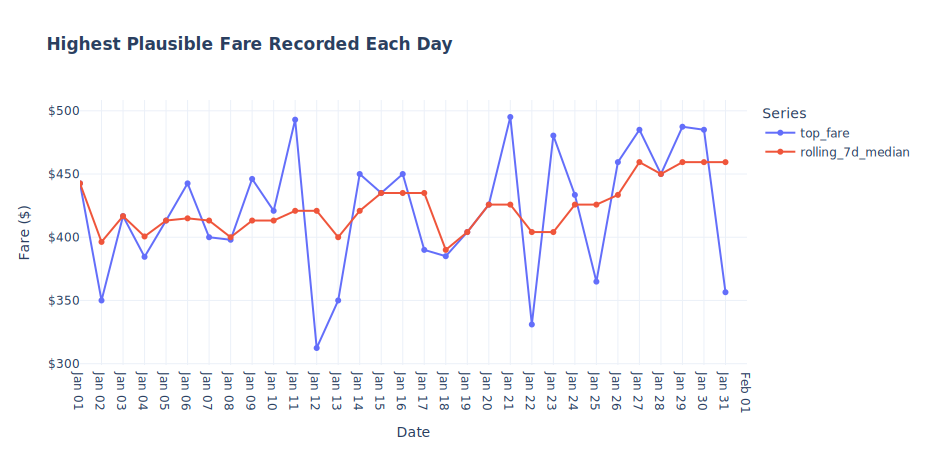

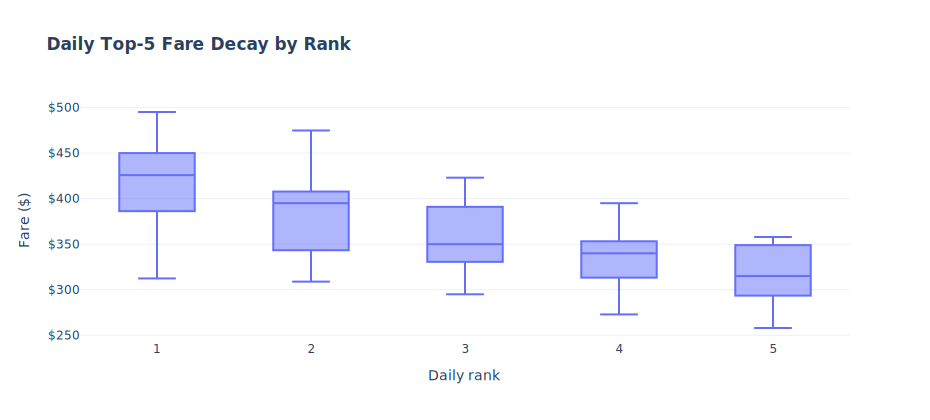

In [4]:
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display

# Visualization is intentionally standardized through pandas on the small run.
# Chart the daily #1 fare from the small sample's top-N output, plus rank decay.
reporter.set_analysis_fn(window_functions_pandas, mode="small")
df = reporter.get_analysis_df(OUT_COLS).copy()
df["pickup_date"] = pd.to_datetime(df["pickup_date"])
start_ts, end_ts = _month_bounds_from_paths(reporter.small_paths)
if start_ts is not None and end_ts is not None:
    df = df[(df["pickup_date"] >= start_ts) & (df["pickup_date"] < end_ts)]

if df.empty:
    display(Markdown("No daily top-fare events passed the small-sample filters."))
else:
    top1 = (
        df[df["fare_rank"] == 1]
        .rename(columns={"fare_amount": "top_fare"})
        .sort_values("pickup_date")
        .copy()
    )
    top1["rolling_7d_median"] = top1["top_fare"].rolling(7, min_periods=1).median()
    highest = top1.loc[top1["top_fare"].idxmax()]
    window_text = (
        f" over {start_ts:%Y-%m-%d} to {(end_ts - pd.Timedelta(days=1)):%Y-%m-%d}"
        if start_ts is not None and end_ts is not None
        else ""
    )
    display(
        Markdown(
            f"**Small-sample top-fare sequence{window_text}:** highest daily top fare was "
            f"**${highest.top_fare:.2f}** on **{highest.pickup_date:%Y-%m-%d}**; "
            f"median daily top fare was **${top1.top_fare.median():.2f}**."
        )
    )

    fig = px.line(
        top1,
        x="pickup_date",
        y=["top_fare", "rolling_7d_median"],
        markers=True,
        title="<b>Highest Plausible Fare Recorded Each Day</b><br><sup>Small sample; pickup dates bounded to the input month</sup>",
        labels={"pickup_date": "Date", "value": "Fare ($)", "variable": "Series"},
    )
    fig.update_layout(
        template="plotly_white", yaxis_tickformat="$,.0f", width=930, height=450
    )
    if start_ts is not None and end_ts is not None:
        fig.update_xaxes(range=[start_ts, end_ts], dtick="D7", tickformat="%b %d")
    fig.show()

    rank_df = df.copy()
    rank_df["fare_rank"] = rank_df["fare_rank"].astype("int64").astype(str)
    fig2 = px.box(
        rank_df,
        x="fare_rank",
        y="fare_amount",
        points=False,
        title="<b>Daily Top-5 Fare Decay by Rank</b><br><sup>Small sample, plausible fare events only</sup>",
        labels={"fare_rank": "Daily rank", "fare_amount": "Fare ($)"},
    )
    fig2.update_layout(
        template="plotly_white", yaxis_tickformat="$,.0f", width=930, height=420
    )
    fig2.show()

## Performance Comparison

In [5]:
reporter.show_scorecard("Ordered Window Function Performance")

#### Ordered Window Function Performance — Single Month · Uncapped

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | 0.1227s | 1.2×       | 613 MB     | —        |
| daft v0.7.15             | 0.1164s | 1.2×       | 269 MB     | —        |
| dask v2026.6.0           | 0.1439s | 1.0×       | 562 MB     | —        |
| duckdb v1.5.4            | 0.0532s | 2.7×       | 153 MB     | —        |
| duckdb-capped v1.5.4     | 0.0545s | 2.6×       | 150 MB     | —        |
| polars v1.41.2           | 0.0420s | **3.4×**   | 456 MB     | —        |
| polars-streaming v1.41.2 | 0.0426s | 3.4×       | 430 MB     | —        |

*✅ 7 engine(s) agree (155 rows)*

#### Ordered Window Function Performance — Full Window · 1024 MB Cap

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | **OOM** | —          | ≥1030 MB   | ≥1.01    |
| daft v0.7.15             | **OOM** | —          | ≥1025 MB   | ≥1.00    |
| dask v2026.6.0           | **OOM** | —          | ≥1049 MB   | ≥1.02    |
| duckdb v1.5.4            | 0.9324s | 1.0×       | 231 MB     | 0.23     |
| duckdb-capped v1.5.4     | 0.9103s | **1.0×**   | 235 MB     | 0.23     |
| polars v1.41.2           | **OOM** | —          | ≥1075 MB   | ≥1.05    |
| polars-streaming v1.41.2 | **OOM** | —          | ≥1052 MB   | ≥1.03    |

*✅ 2 engine(s) agree (3,655 rows)*